
```
├── submission
│   ├── Task1_Data
│   │   ├── Company 1
│   │   │   ├── Company ESG Report
│   │   │   ├── MSIC report
│   │   │   ├── SPGlobal report
│   │   │   ├── PDF docs           (Run pdfminer package to obtain)
│   │   │   ├── PDF embedding      (Run pdfminer package to obtain)
│   │   └── Metadata               ("Company Name", "Sector", "PDF_link", "MSCI", "SPGlobal")
│   │   ├── Company 2
│   │   ├── Company 3
│   │   ├── ...
│   │   ├── Company 50
│   ├── Task2_Analysis
│   └── Task3_Visualization
└── ...
```

```
Company 1:
---------------------------
Company ESG Report:   0.0
MSIC report:          0.0
SPGlobal report:      0.1
PDF docs:             0.1
PDF embedding:        0.1
Metadata:             0.5

Total: 0.8
---------------------------
Company 2:
---------------------------
Company ESG Report:   0.1
MSIC report:          0.1
SPGlobal report:      0.0
PDF docs:             0.1
PDF embedding:        0.1
Metadata:             0.0

Total: 0.4
---------------------------
Company 3-50:
---------------------------
Company ESG Report:   0.1
MSIC report:          0.1
SPGlobal report:      0.1
PDF docs:             0.1
PDF embedding:        0.1
Metadata:             0.5

Total: 48
---------------------------
Bonus Company 51-55:
---------------------------
Company ESG Report:   0.1
MSIC report:          0.1
SPGlobal report:      0.1
PDF docs:             0.1
PDF embedding:        0.1
Metadata:             0.5

Total: 5
---------------------------
Your total mark is 0.8+0.4+48+5 = 54.2
---------------------------
```

Metadata is the most important part you are required to submit, the teaching team will go through to each each metadata mannually. Therefore, please keep sure the submission is on the right track. Here's one example of metadata.json with 2 companies:

Summaries the information in metadata, and here is the example of Tencent Holdings and Meta Platforms:

```
[
  {
    "Company": "Tencent Holdings",
    "PDF_link": "https://static.www.tencent.com/uploads/2024/04/08/a041eba55b96c7952e26180a2c7cdd28.pdf",
    "Sector": "Technology",
    "MSCI":{
      "MASI_Link":"https://www.msci.com/our-solutions/esg-investing/esg-ratings-climate-search-tool/issuer/tencent-holdings-limited/IID000000002149109",
      "MSCI_Score": "BBB",
      "Corporate_Behavior": "lag",
      "Access_to_Finance": "lag",
      "Corporate_Governance": "average",
      "Human_Capital_Development": "average",
      "Carbon_Emissions": "average",
      "Privacy_Data_Security": "lead"
    },
    "SPGlobal":{
      "SPGlobal_link": "https://www.spglobal.com/esg/scores/results?cid=4329847",
      "SPGlobal_Score": 59,
      "SPGlobal_E": 75,
      "SPGlobal_S": 55,
      "SPGlobal_G": 53,
      "Industry_Mean_E": 22,
      "Industry_Max_E": 79,
      "Industry_Mean_S": 25,
      "Industry_Max_S": 79,
      "Industry_Mean_G": 34,
      "Industry_Max_G": 88,
      "Cybersecurity_and_System_Availability": 75,
      "Human_Rights": 12,
      "Human_Capital_Management": 66,
      "Business_Ethics": 47,
      "Climate_Strategy": 70,
      "Environmental_Policy": 83,
      "Corporate_Governance": 49,
      "Customer_Relations": 72,
      "Privacy_Protection":50
    }
  },

  {
    "Company": "Meta Platforms",
    "PDF_link": "https://sustainability.atmeta.com/wp-content/uploads/2024/08/Meta-2024-Sustainability-Report.pdf",
    "Sector": "Technology",
    "MSCI":{
      "MASI_Link":"https://www.msci.com/our-solutions/esg-investing/esg-ratings-climate-search-tool/issuer/meta-platforms-inc/IID000000002638948",
      "MSCI_Score": "B",
      "Corporate_Behavior": "lag",
      "Corporate_Governance": "average",
      "Human_Capital_Development": "average",
      "Carbon_Emissions": "average",
      "Privacy_Data_Security": "average"
    },
    "SPGlobal": {
      "SPGlobal_link": "https://www.spglobal.com/esg/scores/results?cid=4144156",
      "SPGlobal_Score": 29,
      "SPGlobal_E": 58,
      "SPGlobal_S": 18,
      "SPGlobal_G": 26,
      "Industry_Mean_E": 18,
      "Industry_Max_E": 83,
      "Industry_Mean_S": 20,
      "Industry_Max_S": 79,
      "Industry_Mean_G": 27,
      "Industry_Max_G": 68,
      "Cybersecurity_and_System_Availability": 27,
      "Human_Capital_Management": 11,
      "Business_Ethics": 2,
      "Climate_Strategy": 65,
      "Customer_Relations": 8,
      "Privacy_Protection":6,
      "Innovation_Management": 16,
      "Talent_Attraction_and_Retention": 30,
      "Content_Responsibility_and_Moderation": 12
    }
  }
]
```

In [381]:
import os
os.chdir('..')

## 1. Obtain Company ESG Report
Obtain the company ESG report from the web, and store the PDF into the file. Please get the company name from the "company_list.csv" file.

In [382]:
%pip install pandas matplotlib numpy -q

In [383]:
import pandas as pd

df = pd.read_csv('/Users/chenwanqiu/Downloads/llm_esg_judge-2_/cookbooks/data/company_list.csv')
df

,Company,Sector
0,Walmart,Retailing
1,Amazon,Retailing
2,Exxon Mobil,Energy
3,Apple,Technology
4,UnitedHealth Group,Health Care
...,...,...
995,TTEC Holdings,Technology
996,ProFrac Holding,Energy
997,Summit Materials,Materials
998,Teladoc Health,Health Care


In [384]:
# Select Company Name: Apple, Meta, and Tencent
tech_df = df[df['Company'].isin(['Apple', 'Meta Platforms'])]
tech_df

,Company,Sector
3,Apple,Technology
30,Meta Platforms,Technology


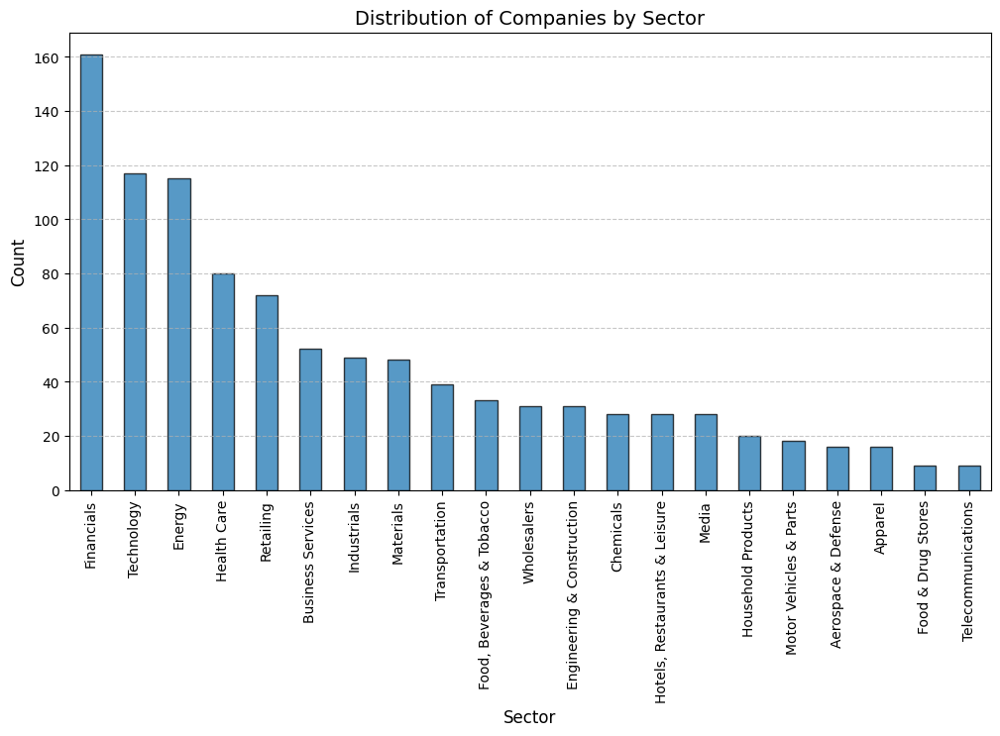

In [385]:
# Add one column to the DataFrame named "PDF"
import matplotlib.pyplot as plt

# Plot histogram for sectors
plt.figure(figsize=(12, 6))
df['Sector'].value_counts().plot(kind='bar', alpha=0.75, edgecolor='black')
plt.title('Distribution of Companies by Sector', fontsize=14)
plt.xlabel('Sector', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 2. Obtain MSCI & SPGlobal Rating


## 3. Parse PDF Docs


In [386]:
%pip install pdf2image -q
%pip install pdfminer -q
%pip install pdfminer.six -q
%pip install openai==1.60.1 -q
%pip install scikit-learn -q
%pip install rich -q
%pip install tqdm -q
%pip install pandas -q
%pip install python-dotenv -q
%pip install pyyaml -q
%pip install ollama -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [387]:
%conda install -c conda-forge poppler  -y 

Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [388]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [389]:
# Imports
from pdf2image import convert_from_path
from pdf2image.exceptions import (
    PDFInfoNotInstalledError,
    PDFPageCountError,
    PDFSyntaxError
)
from pdfminer.high_level import extract_text
import base64
import io
import os
import concurrent.futures
from tqdm import tqdm
from openai import OpenAI
import re
import pandas as pd 
from sklearn.metrics.pairwise import cosine_similarity
import json
import numpy as np
from rich import print
import ollama
from ast import literal_eval

In [390]:
def convert_doc_to_images(path):
    images = convert_from_path(path)
    return images

def extract_text_from_doc(path, page_numbers=None):
    text = extract_text(path, page_numbers=page_numbers)
    return text

In [391]:
company_name = "Valero Energy"
file_path = f"/Users/chenwanqiu/Downloads/llm_esg_judge-2_/submission/Task1_Data/{company_name}/Report.pdf"
images = convert_doc_to_images(file_path)
len(images)

80

In [392]:
text = extract_text_from_doc(
    file_path, 
    # page_numbers=range(10)
    )

text[:100]

'ESG Report\n\nThe world requires reliable, affordable and sustainable energy, \nand we see this as an o'

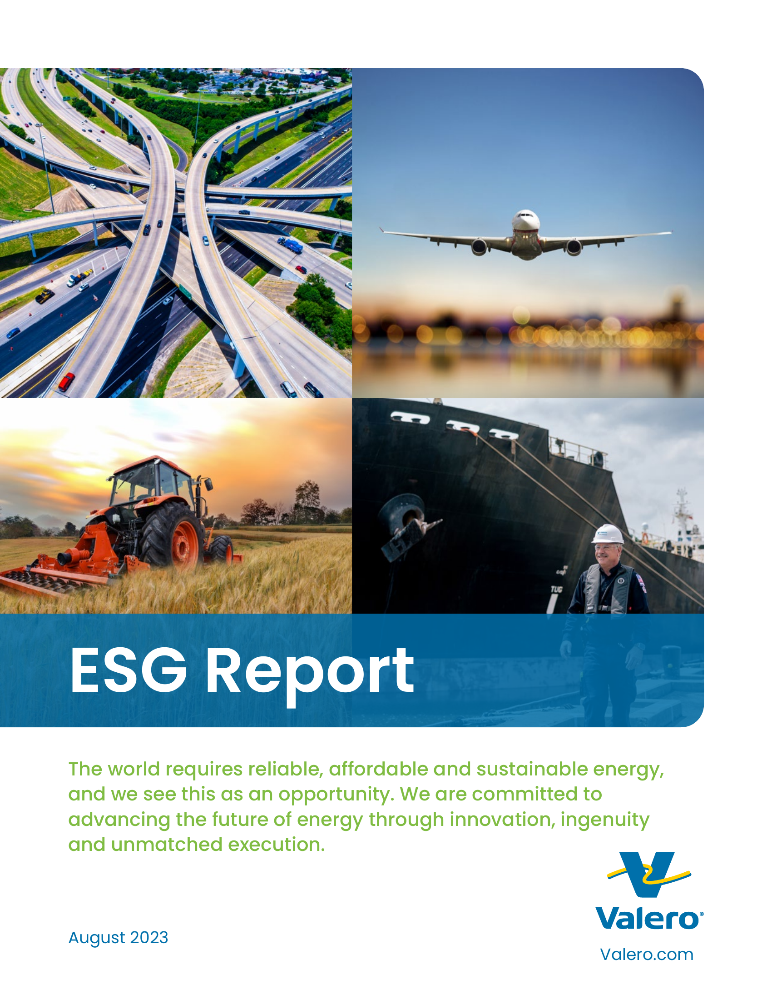

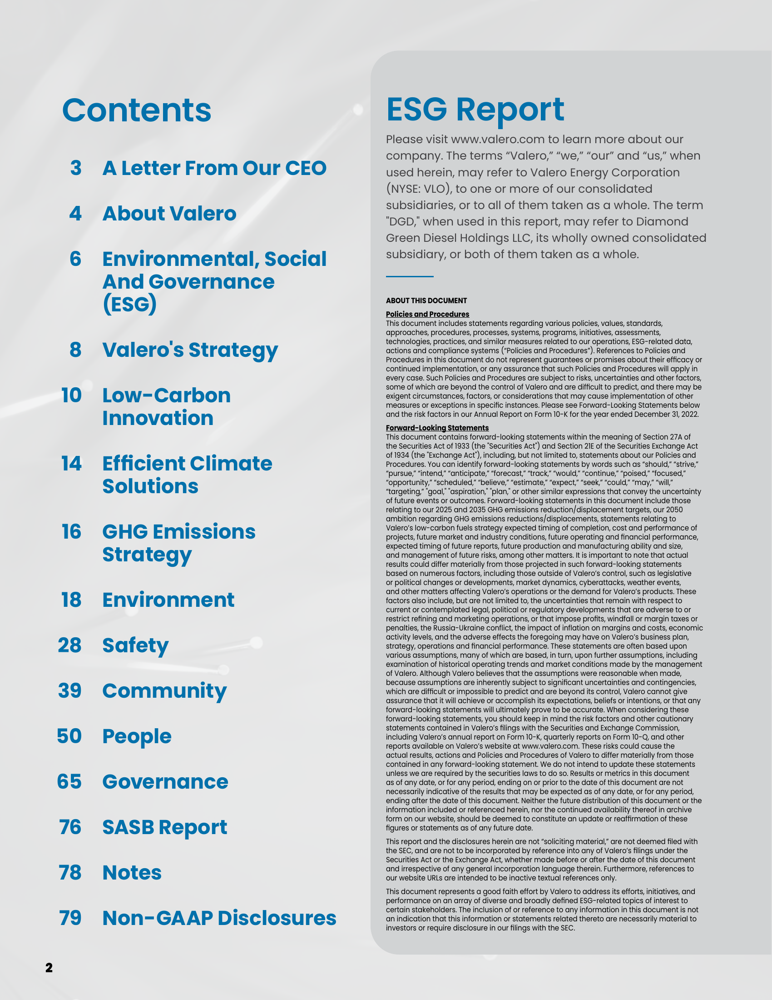

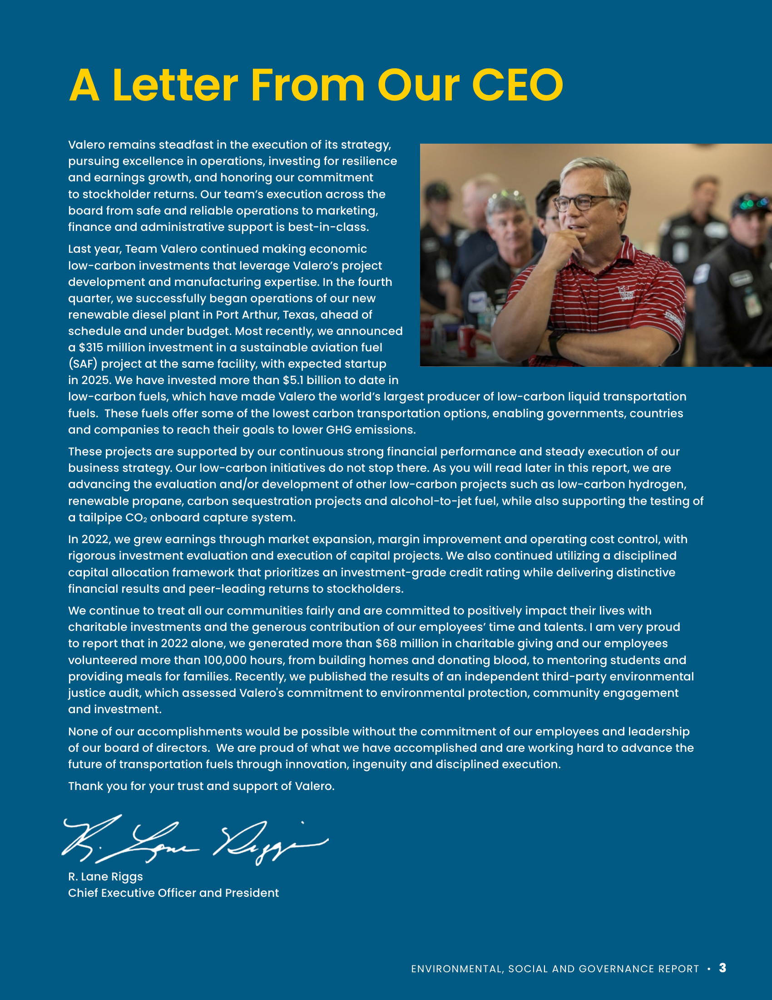

In [393]:
for img in images[:3]:
    display(img)

In [394]:
doc = {
    "filename": f"{company_name}_PDF",
    'text': text,
    }

doc['pages_description'] = []

# Saving result to file for later
json_path = f"/Users/chenwanqiu/Downloads/llm_esg_judge-2_/submission/Task1_Data/{company_name}/pdf_docs.json"

with open(json_path, 'w') as f:
    json.dump(doc, f)

## 4. PDF Embedding
Here we get the embedding model to convert the text into the vector. But we first need to split the large PDF into small chunks. Please store the vector in the csv file.

In [395]:
# Chunking content by page and merging together slides text & description if applicable
content = []

# Removing first slide as well
text = doc['text'].split('\f')[1:]
description = doc['pages_description']
description_indexes = []
for i in range(len(text)):
    slide_content = text[i] + '\n'
    # Trying to find matching slide description
    slide_title = text[i].split('\n')[0]
    for j in range(len(description)):
        description_title = description[j].split('\n')[0]
        if slide_title.lower() == description_title.lower():
            slide_content += description[j].replace(description_title, '')
            # Keeping track of the descriptions added
            description_indexes.append(j)
    # Adding the slide content + matching slide description to the content pieces
    content.append(slide_content) 
    
# Adding the slides descriptions that weren't used
for j in range(len(description)):
    if j not in description_indexes:
        content.append(description[j])
        
# Cleaning up content
# Removing trailing spaces, additional line breaks, page numbers and references to the content being a slide
import textwrap
clean_content = []
for c in content:
    text = c.replace(' \n', '').replace('\n\n', '\n').replace('\n\n\n', '\n').strip()
    text = re.sub(r"(?<=\n)\d{1,2}", "", text)
    text = re.sub(r"\b(?:the|this)\s*slide\s*\w+\b", "", text, flags=re.IGNORECASE)
    text_chunk = textwrap.wrap(text, 1000)

    clean_content += text_chunk
    
for c in clean_content[:3]:
    print(c)
    print("\n\n-------------------------------\n\n")

Contents   3  A Letter From Our CEO   4  About Valero   6  Environmental, Social  And Governance   (ESG)   8  
Valero's Strategy   10  Low-Carbon  Innovation   14   Efficient Climate             Solutions   16  GHG Emissions  
Strategy   18  Environment   28  Safety   39  Community   50  People   65  Governance   76  SASB Report   78  Notes
79  Non-GAAP Disclosures   ESG Report Please visit www.valero.com to learn more about ourcompany. The terms 
“Valero,” “we,” “our” and “us,” whenused herein, may refer to Valero Energy Corporation(NYSE: VLO), to one or more 
of our consolidatedsubsidiaries, or to all of them taken as a whole. The term"DGD," when used in this report, may 
refer to DiamondGreen Diesel Holdings LLC, its wholly owned consolidatedsubsidiary, or both of them taken as a 
whole. ABOUT THIS DOCUMENT Policies and Procedures This document includes statements regarding various policies, 
values, standards,approaches, procedures, processes, systems, programs, initiatives,

-------------------------------

assessments,technologies, practices, and similar measures related to our operations, ESG-related data,actions and 
compliance systems (“Policies and Procedures”). References to Policies andProcedures in this document do not 
represent guarantees or promises about their efficacy orcontinued implementation, or any assurance that such 
Policies and Procedures will apply inevery case. Such Policies and Procedures are subject to risks, uncertainties 
and other factors,some of which are beyond the control of Valero and are difficult to predict, and there may 
beexigent circumstances, factors, or considerations that may cause implementation of othermeasures or exceptions in
specific instances. Please see Forward-Looking Statements belowand the risk factors in our Annual Report on Form 
10-K for the year ended December 31, 2022. Forward-Looking Statements This document contains forward-looking 
statements within the meaning of Section 27A ofthe Securities Act of 1933 (the "Securities Act") and

-------------------------------

Section 21E of the Securities Exchange Actof 1934 (the "Exchange Act"), including, but not limited to, statements 
about our Policies andProcedures. You can identify forward-looking statements by words such as “should,” 
“strive,”“pursue,” “intend,” “anticipate,” “forecast,” “track,” “would,” “continue,” “poised,” 
“focused,”“opportunity,” “scheduled,” “believe,” “estimate,” “expect,” “seek,” “could,” “may,” “will,”“targeting,” 
"goal," "aspiration," "plan," or other similar expressions that convey the uncertaintyof future events or outcomes.
Forward-looking statements in this document include thoserelating to our 2025 and 2035 GHG emissions 
reduction/displacement targets, our 2050ambition regarding GHG emissions reductions/displacements, statements 
relating toValero’s low-carbon fuels strategy expected timing of completion, cost and performance ofprojects, 
future market and industry conditions, future operating and financial performance,expected timing of future 
reports, future production

-------------------------------

In [396]:
# Creating the embeddings
# We'll save to a csv file here for testing purposes but this is where you should load content in your vectorDB.
df = pd.DataFrame(clean_content, columns=['content'])
print(df.shape)
df.head()

(466, 1)

,content
0,Contents 3 A Letter From Our CEO 4 About...
1,"assessments,technologies, practices, and simil..."
2,Section 21E of the Securities Exchange Actof 1...
3,"and manufacturing ability and size,and managem..."
4,"are often based uponvarious assumptions, many ..."


In [397]:
#set up the ollama
#Ollama are not currently compatible with the OpenAI embeddings api
#to use ollama embedding model, run `ollama pull nomic-embed-text`
def get_embeddings(text):
    response = ollama.embeddings(
          model="nomic-embed-text",
          prompt=text,
          # encoding_format="float"
        )
    return response['embedding']

df['embeddings'] = df['content'].apply(lambda x: get_embeddings(x))
df.head()

,content,embeddings
0,Contents 3 A Letter From Our CEO 4 About...,"[0.47304877638816833, 1.2052236795425415, -3.3..."
1,"assessments,technologies, practices, and simil...","[1.292230486869812, 0.9363284111022949, -3.359..."
2,Section 21E of the Securities Exchange Actof 1...,"[0.16786399483680725, 0.5600758790969849, -3.4..."
3,"and manufacturing ability and size,and managem...","[0.4880416989326477, 0.9096580743789673, -3.43..."
4,"are often based uponvarious assumptions, many ...","[1.3728913068771362, 0.9888609647750854, -3.85..."


In [398]:
df.shape

(466, 2)

In [399]:
# Saving locally for later
data_path = f"/Users/chenwanqiu/Downloads/llm_esg_judge-2_/submission/Task1_Data/{company_name}/pdf_embedding.csv"
df.to_csv(data_path, index=False)

## Final check the file list

In [400]:
report_files_path = f"/Users/chenwanqiu/Downloads/llm_esg_judge-2_/submission/Task1_Data/{company_name}"

import os
all_items = os.listdir(report_files_path)
files = [item for item in all_items if os.path.isfile(os.path.join(report_files_path, item))]
files

['ESG Ratings & Climate Search Tool - MSCI.pdf',
 'pdf_embedding.csv',
 'pdf_docs.json',
 'Report.pdf',
 'S&P Global.pdf']